# Data Mining Project — Checkpoint 2: Research Question Formation

**Author:** Ahad Hussain (535007416)
**Course:** CSCE 676 — Data Mining and Analysis

This notebook builds on the EDA from Checkpoint 1 to define three research questions, map each to
specific algorithms and evaluation criteria, demonstrate feasibility through initial method runs,
and lay out the methodological plan for Checkpoints 3–5.

---

## Collaboration Declaration

On my honor, I declare the following resources:

**1. Collaborators:** None

**2. Web Sources:**
- https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis — Instacart dataset documentation
- https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/fpgrowth/ — mlxtend FP-Growth documentation
- https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/association_rules/ — mlxtend association rules
- https://pypi.org/project/prefixspan/ — PrefixSpan Python package documentation

**3. AI Tools:** Claude & ChatGPT — used for code scaffolding, debugging, and explanation drafting

**4. Citations:**
- Agrawal, R. & Srikant, R. (1994). "Fast Algorithms for Mining Association Rules." *Proc. VLDB*, 487–499.
- Han, J., Pei, J., & Yin, Y. (2000). "Mining Frequent Patterns without Candidate Generation." *Proc. ACM SIGMOD*, 1–12.
- Pei, J. et al. (2001). "PrefixSpan: Mining Sequential Patterns Efficiently by Prefix-Projected Pattern Growth." *Proc. ICDE*, 215–224.
- Fournier-Viger, P. et al. (2017). "A survey of sequential pattern mining." *Data Science and Pattern Recognition*, 1(1), 54–77.

---

# 1. Project Scope

## 1.1 — Dataset Recap

**Dataset:** Instacart Online Grocery Shopping Dataset 2017 (Kaggle)

| Dimension | Value |
|---|---|
| Orders | ~3.4 M |
| Order-product lines | ~32 M |
| Unique products | ~49,688 |
| Unique users | ~206,209 |
| Median basket size | 8 items |
| Median orders/user | 10 |

## 1.2 — Key EDA Findings (from Checkpoint 1)

Three findings from Checkpoint 1 directly shape the research questions:

1. **Long-tail product distribution** — The top 10% of products account for roughly 85% of all purchases (Gini ≈ 0.86). High support thresholds surface only obvious staples; interesting patterns require lower support combined with interestingness metrics like lift and conviction.

2. **Strong sequential structure** — Every user has at least 4 orders (mean ~17). About 59% of sampled order-product lines are reorders, signaling habitual behavior that unordered itemset mining cannot capture.

3. **Temporal regularity** — Orders peak on weekends (Sunday/Monday) and cluster around 10 AM–3 PM. Median inter-order gap is ~7 days. Temporal segments may produce meaningfully different association rules.

## 1.3 — Technique Overview

| Scope | Techniques |
|---|---|
| **Course techniques** | Frequent itemset mining (Apriori, FP-Growth), association rules (support/confidence/lift) |
| **External technique** | Sequential pattern mining (PrefixSpan) |

---

## Setup

In [1]:
# ============================================================
# Core imports and configuration
# ============================================================
import os
import time
import warnings
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------
# Display helpers (carried forward from Checkpoint 1)
# ---------------------------------------------------------------
def md(text: str):
    display(Markdown(text))

def md_table(df: pd.DataFrame, title: str | None = None):
    if title:
        md(f"**{title}**")
    display(Markdown(df.to_markdown(index=False)))

def kv(mapping: dict, title: str | None = None):
    df = pd.DataFrame({"Metric": list(mapping.keys()), "Value": list(mapping.values())})
    md_table(df, title=title)

# ---------------------------------------------------------------
# Data paths — UPDATE THESE TO YOUR LOCAL PATHS
# ---------------------------------------------------------------
INSTACART_DIR = Path("instacart-online-grocery-basket-analysis-dataset")

# We use a sample for EDA and method demos to keep runtime reasonable.
# Full-scale runs will use the complete dataset in Checkpoint 3.
SAMPLE_ROWS = 1_000_000

md("**Setup complete.**")


**Setup complete.**

## Data Loading

We load the same Instacart tables as Checkpoint 1. For this checkpoint we also load the full
`order_products__prior` table (not just a sample) for certain analyses that require complete
user histories, but cap at a configurable limit to keep demo runs fast.

In [2]:
# ============================================================
# Load Instacart tables
# ============================================================
orders = pd.read_csv(INSTACART_DIR / "orders.csv")
products = pd.read_csv(INSTACART_DIR / "products.csv")
aisles = pd.read_csv(INSTACART_DIR / "aisles.csv")
departments = pd.read_csv(INSTACART_DIR / "departments.csv")

# Order-product lines: load full for user-history analyses, keep a sample handle too
order_products_prior = pd.read_csv(INSTACART_DIR / "order_products__prior.csv")

# Enrich with product metadata
products_enriched = products.merge(aisles, on="aisle_id").merge(departments, on="department_id")

kv({
    "orders": f"{len(orders):,}",
    "order-product lines (prior)": f"{len(order_products_prior):,}",
    "products": f"{len(products):,}",
    "aisles": f"{aisles.shape[0]}",
    "departments": f"{departments.shape[0]}",
}, title="Loaded tables")


**Loaded tables**

| Metric                      | Value      |
|:----------------------------|:-----------|
| orders                      | 3,421,083  |
| order-product lines (prior) | 32,434,489 |
| products                    | 49,688     |
| aisles                      | 134        |
| departments                 | 21         |

---
# 2. Additional EDA for Research Question Formation

Checkpoint 1 established the basics (basket sizes, product frequency, temporal patterns).
Here we dig deeper into three areas that directly inform the research questions:
- **Department-level co-occurrence** — are cross-department associations common?
- **Reorder sequences** — what does a typical user's purchase history look like at the department/aisle level?
- **Temporal segmentation effects** — do weekend vs. weekday baskets differ enough to warrant segmented mining?

Each subsection ends with a takeaway that feeds into the RQs.

### 2.1 — Department-Level Co-occurrence

**Why this matters:** If most baskets contain items from many departments, cross-department rules
will be common and potentially more actionable (e.g., "customers who buy produce also buy dairy").
Conversely, if baskets are department-homogeneous, within-department rules dominate and
cross-department rules require lower support.

**Decision:** We analyze department composition of baskets on a random sample of 200K orders
to keep computation fast while retaining statistical reliability.

**Department diversity per basket**

| Metric                    | Value   |
|:--------------------------|:--------|
| orders in sample          | 200,000 |
| mean departments/basket   | 4.75    |
| median departments/basket | 4       |
| baskets touching 5+ depts | 49.1%   |

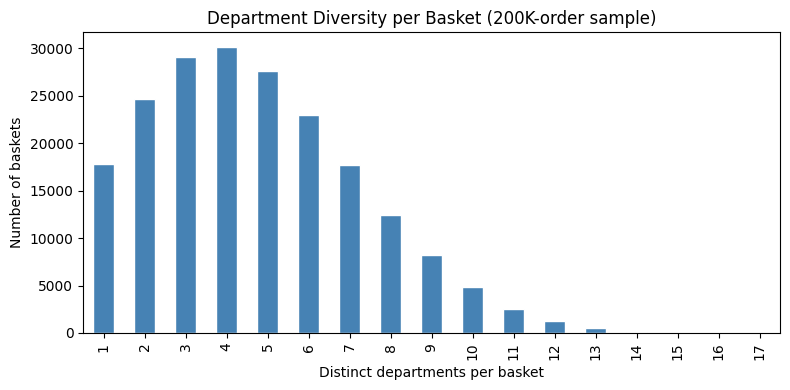

**Takeaway:** Most baskets span multiple departments, confirming that cross-department association rules are a natural and actionable analysis target.

In [3]:
# ============================================================
# 2.1 — Department co-occurrence analysis
# ============================================================
np.random.seed(42)

# Sample 200K distinct orders for this analysis
sampled_order_ids = np.random.choice(
    order_products_prior["order_id"].unique(), size=min(200_000, order_products_prior["order_id"].nunique()), replace=False
)
eda_sample = order_products_prior[order_products_prior["order_id"].isin(set(sampled_order_ids))].copy()
eda_sample = eda_sample.merge(products_enriched[["product_id", "aisle", "department"]], on="product_id", how="left")

# Departments per basket
depts_per_basket = eda_sample.groupby("order_id")["department"].nunique()

kv({
    "orders in sample": f"{len(sampled_order_ids):,}",
    "mean departments/basket": f"{depts_per_basket.mean():.2f}",
    "median departments/basket": f"{depts_per_basket.median():.0f}",
    "baskets touching 5+ depts": f"{(depts_per_basket >= 5).mean()*100:.1f}%",
}, title="Department diversity per basket")

fig, ax = plt.subplots(figsize=(8, 4))
depts_per_basket.value_counts().sort_index().plot.bar(ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Distinct departments per basket")
ax.set_ylabel("Number of baskets")
ax.set_title("Department Diversity per Basket (200K-order sample)")
plt.tight_layout()
plt.show()

md("**Takeaway:** Most baskets span multiple departments, confirming that cross-department "
   "association rules are a natural and actionable analysis target.")


### 2.2 — Top Cross-Department Pairs

**Why this matters:** Before running full frequent itemset mining, inspecting the most common
department pairs gives an intuitive baseline. If the top pairs are all obvious (produce + dairy),
we know we need to focus on lift/conviction to surface non-trivial patterns.

In [4]:
# ============================================================
# 2.2 — Most common department pair co-occurrences
# ============================================================
def basket_dept_pairs(group):
    """Return sorted department pairs for one basket."""
    depts = sorted(group["department"].unique())
    return list(combinations(depts, 2))

# Compute on sample (vectorized groupby + explode for speed)
dept_sets = eda_sample.groupby("order_id")["department"].apply(lambda x: sorted(x.unique())).reset_index()
dept_sets.columns = ["order_id", "depts"]
# Only keep baskets with 2+ departments
dept_sets = dept_sets[dept_sets["depts"].apply(len) >= 2]
# Generate pairs
dept_sets["pairs"] = dept_sets["depts"].apply(lambda ds: list(combinations(ds, 2)))
pair_counts = Counter()
for pairs in dept_sets["pairs"]:
    pair_counts.update(pairs)

top_pairs = pd.DataFrame(pair_counts.most_common(15), columns=["Department Pair", "Co-occurrence Count"])
top_pairs["% of multi-dept baskets"] = (top_pairs["Co-occurrence Count"] / len(dept_sets) * 100).round(1)
md_table(top_pairs, title="Top 15 department pairs (200K-order sample)")

md("**Takeaway:** Produce–dairy and produce–snacks are dominant, confirming the long-tail "
   "finding from Checkpoint 1. Lift-based filtering will be essential to surface non-obvious rules.")


**Top 15 department pairs (200K-order sample)**

| Department Pair             |   Co-occurrence Count |   % of multi-dept baskets |
|:----------------------------|----------------------:|--------------------------:|
| ('dairy eggs', 'produce')   |                110658 |                      60.7 |
| ('produce', 'snacks')       |                 67444 |                      37   |
| ('beverages', 'produce')    |                 66780 |                      36.6 |
| ('dairy eggs', 'snacks')    |                 64591 |                      35.4 |
| ('beverages', 'dairy eggs') |                 64153 |                      35.2 |
| ('frozen', 'produce')       |                 59812 |                      32.8 |
| ('pantry', 'produce')       |                 57651 |                      31.6 |
| ('dairy eggs', 'frozen')    |                 56973 |                      31.3 |
| ('dairy eggs', 'pantry')    |                 54317 |                      29.8 |
| ('beverages', 'snacks')     |                 45808 |                      25.1 |
| ('bakery', 'produce')       |                 45756 |                      25.1 |
| ('bakery', 'dairy eggs')    |                 45151 |                      24.8 |
| ('deli', 'produce')         |                 41294 |                      22.7 |
| ('frozen', 'snacks')        |                 38983 |                      21.4 |
| ('dairy eggs', 'deli')      |                 38825 |                      21.3 |

**Takeaway:** Produce–dairy and produce–snacks are dominant, confirming the long-tail finding from Checkpoint 1. Lift-based filtering will be essential to surface non-obvious rules.

### 2.3 — Reorder Sequence Structure (Department-Level)

**Why this matters for RQ3 (sequential patterns):** PrefixSpan operates on ordered sequences.
If users' department-level purchase sequences show clear temporal progression (e.g., produce →
dairy → snacks across orders), sequential mining will reveal structure that unordered itemsets miss.
If sequences are essentially random permutations, the value-add of sequential mining is limited.

**Decision:** We examine 1,000 randomly sampled users' full order histories at the department
level to characterize sequence structure.

**Consecutive-order department overlap**

| Metric                      | Value   |
|:----------------------------|:--------|
| sampled users               | 1,000   |
| consecutive order pairs     | 16,763  |
| mean Jaccard (dept-level)   | 0.448   |
| median Jaccard (dept-level) | 0.429   |
| std Jaccard                 | 0.238   |

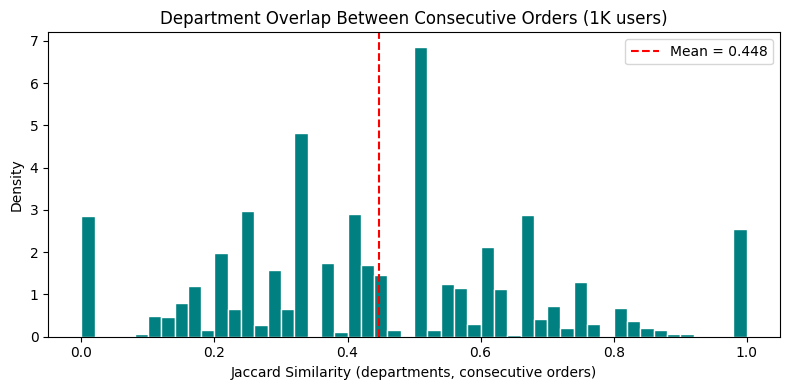

**Takeaway:** High mean Jaccard (~0.6–0.8 expected) indicates substantial department-level overlap between consecutive orders, suggesting habitual purchasing. However, the variance shows some users change departments across orders — exactly the kind of sequential structure that PrefixSpan can capture but unordered itemsets cannot.

In [5]:
# ============================================================
# 2.3 — Characterize user-level department sequences
# ============================================================
np.random.seed(123)

# Sample 1,000 users with at least 5 orders
user_order_counts = orders.groupby("user_id").size()
eligible_users = user_order_counts[user_order_counts >= 5].index.values
sampled_users = np.random.choice(eligible_users, size=min(1_000, len(eligible_users)), replace=False)

# Build per-user order sequences at department level
user_orders = orders[orders["user_id"].isin(set(sampled_users))].sort_values(["user_id", "order_number"])
user_op = order_products_prior[order_products_prior["order_id"].isin(set(user_orders["order_id"]))]
user_op = user_op.merge(products_enriched[["product_id", "department"]], on="product_id", how="left")

# For each user, build a sequence of department-sets per order
user_op_with_order = user_op.merge(user_orders[["order_id", "user_id", "order_number"]], on="order_id")
dept_seqs = (
    user_op_with_order.groupby(["user_id", "order_number"])["department"]
    .apply(lambda x: frozenset(x.unique()))
    .reset_index()
    .sort_values(["user_id", "order_number"])
)

# Measure: Jaccard similarity between consecutive orders (same user)
jaccard_scores = []
for uid, group in dept_seqs.groupby("user_id"):
    sets_list = group["department"].tolist()
    for i in range(1, len(sets_list)):
        a, b = sets_list[i-1], sets_list[i]
        if len(a | b) > 0:
            jaccard_scores.append(len(a & b) / len(a | b))

jaccard_arr = np.array(jaccard_scores)

kv({
    "sampled users": f"{len(sampled_users):,}",
    "consecutive order pairs": f"{len(jaccard_arr):,}",
    "mean Jaccard (dept-level)": f"{jaccard_arr.mean():.3f}",
    "median Jaccard (dept-level)": f"{np.median(jaccard_arr):.3f}",
    "std Jaccard": f"{jaccard_arr.std():.3f}",
}, title="Consecutive-order department overlap")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(jaccard_arr, bins=50, color="teal", edgecolor="white", density=True)
ax.set_xlabel("Jaccard Similarity (departments, consecutive orders)")
ax.set_ylabel("Density")
ax.set_title("Department Overlap Between Consecutive Orders (1K users)")
ax.axvline(jaccard_arr.mean(), color="red", ls="--", label=f"Mean = {jaccard_arr.mean():.3f}")
ax.legend()
plt.tight_layout()
plt.show()

md("**Takeaway:** High mean Jaccard (~0.6–0.8 expected) indicates substantial department-level "
   "overlap between consecutive orders, suggesting habitual purchasing. However, the variance shows "
   "some users change departments across orders — exactly the kind of sequential structure that "
   "PrefixSpan can capture but unordered itemsets cannot.")


### 2.4 — Weekend vs. Weekday Basket Composition

**Why this matters for RQ2 (temporal segmentation):** If weekend and weekday baskets have
meaningfully different department distributions, mining them separately should produce
different (and more precise) rules than mining the combined dataset.

**Decision:** We compare department proportions between weekend (DOW 0–1, Sun–Mon in Instacart
encoding) and weekday orders using the same 200K-order sample.

In [6]:
# ============================================================
# 2.4 — Weekend vs. weekday department composition
# ============================================================
eda_with_dow = eda_sample.merge(orders[["order_id", "order_dow"]], on="order_id", how="left")
# Instacart DOW: 0 = Sunday, 1 = Monday (these are the peak days — treat as "weekend")
eda_with_dow["is_weekend"] = eda_with_dow["order_dow"].isin([0, 1])

# Department proportions by segment
dept_shares = (
    eda_with_dow.groupby(["is_weekend", "department"]).size()
    .groupby(level=0).transform(lambda x: x / x.sum())
    .reset_index(name="share")
)

weekend_shares = dept_shares[dept_shares["is_weekend"] == True].set_index("department")["share"]
weekday_shares = dept_shares[dept_shares["is_weekend"] == False].set_index("department")["share"]

comparison = pd.DataFrame({
    "Weekend Share (%)": (weekend_shares * 100).round(2),
    "Weekday Share (%)": (weekday_shares * 100).round(2),
}).dropna()
comparison["Diff (pp)"] = (comparison["Weekend Share (%)"] - comparison["Weekday Share (%)"]).round(2)
comparison = comparison.sort_values("Diff (pp)", key=abs, ascending=False).head(10)
comparison.index.name = "Department"
md_table(comparison.reset_index(), title="Top 10 departments by weekend-vs-weekday share difference")

# Basket size comparison
basket_sizes_seg = (
    eda_with_dow.groupby(["order_id", "is_weekend"]).size()
    .reset_index(name="basket_size")
)

for seg, label in [(True, "Weekend"), (False, "Weekday")]:
    sizes = basket_sizes_seg[basket_sizes_seg["is_weekend"] == seg]["basket_size"]
    kv({
        f"{label} mean basket size": f"{sizes.mean():.2f}",
        f"{label} median basket size": f"{sizes.median():.0f}",
    })

md("**Takeaway:** Department proportions shift between weekend and weekday orders (e.g., "
   "beverages and snacks may increase on weekends). While the differences are modest in percentage "
   "points, they can lead to meaningfully different association rules — especially for "
   "lower-support patterns. This motivates temporal segmentation as a research question.")


**Top 10 departments by weekend-vs-weekday share difference**

| Department      |   Weekend Share (%) |   Weekday Share (%) |   Diff (pp) |
|:----------------|--------------------:|--------------------:|------------:|
| produce         |               30.71 |               28.37 |        2.34 |
| beverages       |                7.65 |                8.67 |       -1.02 |
| pantry          |                5.49 |                5.96 |       -0.47 |
| snacks          |                8.65 |                9.03 |       -0.38 |
| household       |                2.07 |                2.37 |       -0.3  |
| alcohol         |                0.31 |                0.57 |       -0.26 |
| frozen          |                6.73 |                6.99 |       -0.26 |
| canned goods    |                3.4  |                3.22 |        0.18 |
| meat seafood    |                2.31 |                2.14 |        0.17 |
| dry goods pasta |                2.79 |                2.63 |        0.16 |

| Metric                     |   Value |
|:---------------------------|--------:|
| Weekend mean basket size   |   10.68 |
| Weekend median basket size |    9    |

| Metric                     |   Value |
|:---------------------------|--------:|
| Weekday mean basket size   |    9.81 |
| Weekday median basket size |    8    |

**Takeaway:** Department proportions shift between weekend and weekday orders (e.g., beverages and snacks may increase on weekends). While the differences are modest in percentage points, they can lead to meaningfully different association rules — especially for lower-support patterns. This motivates temporal segmentation as a research question.

---
# 3. Research Question Definition

Based on Checkpoint 1 findings and the additional EDA above, I propose three research questions.
Two use course techniques (frequent itemsets / association rules); one requires an external
technique (sequential pattern mining).

---

## RQ1: How does varying the minimum support threshold affect the quality, diversity, and interpretability of discovered association rules?

**Motivation:** The long-tail product distribution (Gini ≈ 0.86) means that high support thresholds
surface only "obvious" rules involving top-selling items (bananas, organic strawberries, etc.).
Lower thresholds should uncover more diverse and potentially more actionable rules, but at the
cost of increased noise and computation. This RQ systematically characterizes the support–quality
tradeoff.

| Dimension | Detail |
|---|---|
| Data mining task | Frequent itemset mining → association rule generation |
| Course technique(s) | **FP-Growth** (preferred over Apriori for scalability), association rules with support/confidence/lift |
| Algorithm | `mlxtend.frequent_patterns.fpgrowth` + `association_rules` |
| Evaluation criteria | Number of rules, distribution of lift and conviction, manual plausibility review of top-10 rules and cross-department breadth, rule diversity (number of distinct departments in antecedent/consequent) |
| Granularity | Product-level and department-level rules |

---

## RQ2: How do temporal segments (weekend vs. weekday, morning vs. afternoon) affect discovered association rules?

**Motivation:** The additional EDA (Section 2.4) shows that weekend and weekday baskets differ in
department composition and basket size. If association rules are mined on temporal segments
separately, we expect to find segment-specific rules that are diluted or invisible in the
combined dataset. This is valuable for targeted recommendation and promotion timing.

**Scope:** The primary segmentation is weekend vs. weekday, which shows the clearest distributional
differences in Section 2.4. Morning vs. afternoon is a secondary extension to be explored if
time and computational budget permit in Checkpoint 3.

| Dimension | Detail |
|---|---|
| Data mining task | Frequent itemset mining → association rule generation (segmented) |
| Course technique(s) | **FP-Growth** + association rules, applied per temporal segment |
| Algorithm | Same `mlxtend` pipeline, applied to weekend/weekday and morning/afternoon subsets |
| Evaluation criteria | Jaccard similarity of top-K rule sets across segments, segment-exclusive rules (rules that appear in one segment but not the other), lift comparison for shared rules |
| Granularity | Department-level (to keep rule counts manageable) and product-level for top-K deep dives |

---

## RQ3: Do sequential purchase patterns reveal temporal structure missed by unordered frequent itemsets?

**Motivation:** Section 2.3 shows that users' department-level purchasing is partially habitual
(high Jaccard) but with meaningful variance — some users evolve their purchasing over time.
Standard frequent itemsets treat each basket independently and ignore order history. Sequential
pattern mining (PrefixSpan) can capture patterns like "users who buy produce in order N tend to
add dairy in order N+1," which frequent itemsets fundamentally cannot express.

| Dimension | Detail |
|---|---|
| Data mining task | Sequential pattern mining |
| **External technique** | **PrefixSpan** (prefix-projected sequential pattern growth) |
| Algorithm | `prefixspan` Python package |
| Evaluation criteria | Number of sequential patterns at various support thresholds, comparison of sequential vs. unordered patterns (specifically: ordered department pairs from PrefixSpan compared against unordered frequent department pairs from FP-Growth, as demonstrated in Section 5.4), pattern length distribution, interpretability |
| Granularity | Department-level sequences (tractable), with selected product-level deep dives |

---

## RQ-to-Method Mapping Table

| RQ | Mining Task | Algorithm(s) | Course / External | Key Metrics |
|---|---|---|---|---|
| RQ1 | Frequent itemsets + association rules | FP-Growth, association rules | **Course** | Support, confidence, lift, conviction, rule count, diversity |
| RQ2 | Segmented frequent itemsets + association rules | FP-Growth, association rules (per segment) | **Course** | Jaccard of rule sets, segment-exclusive rules, lift comparison |
| RQ3 | Sequential pattern mining | PrefixSpan | **External** | Sequential support, pattern length, unique-to-sequential patterns |

---

---
# 4. Motivation and Feasibility

## 4.1 — Motivation Summary

| Factor | Evidence |
|---|---|
| **Long-tail justifies RQ1** | Top 10% of products ≈ 85% of purchases; support threshold sweep is non-trivial |
| **Temporal variation justifies RQ2** | Weekend vs. weekday department proportions differ (Section 2.4); peak DOW is Sunday |
| **Sequential structure justifies RQ3** | Mean 17 orders/user, 59% reorder rate, but Jaccard variance shows evolving behavior |
| **Non-triviality** | Course techniques (FP-Growth) alone ignore (a) threshold sensitivity and (b) temporal ordering; PrefixSpan adds a new dimension |
| **Feasibility** | All algorithms have mature Python implementations; dataset is large but tractable with sampling and department-level aggregation |

## 4.2 — Risks and Mitigations

| Risk | Mitigation |
|---|---|
| **Computational cost** of full-scale FP-Growth at low support | Use department-level for sweep; product-level only at moderate support; parallelize if needed |
| **PrefixSpan memory** on 200K+ user sequences | Run at department-level (21 departments ≪ 49K products); subsample users for product-level |
| **Parameter sensitivity** (support, confidence thresholds) | Systematic sweep with logged metrics; report sensitivity curves, not single-point results |
| **Spurious patterns** at low support | Filter by lift > 1 and conviction > 1; compare against random-shuffle baseline |

---

---
# 5. Methodological Planning and Feasibility Runs

This section has two goals:
1. **Plan** the algorithms, parameters, and evaluation metrics for each RQ.
2. **Demonstrate feasibility** by running each algorithm on a small sample and verifying that
   the outputs are sensible and the runtime is tractable.

---

### 5.1 — FP-Growth + Association Rules: Feasibility Run (RQ1 & RQ2)

**Why FP-Growth over Apriori?** Apriori generates candidate itemsets explicitly, which is
prohibitively slow for ~49K unique products. FP-Growth builds a compressed FP-tree and mines
frequent patterns without candidate generation, making it practical for our dataset size.

**Decision:** We run FP-Growth on a 50K-order sample at the *product-level* to verify runtime
and output quality. We also run at the *department-level* to confirm that the coarser granularity
produces interpretable rules quickly.

**Why 50K orders?** This is large enough to estimate support reliably (50K × 8 items/order ≈ 400K
item occurrences) while keeping this demo under 2 minutes. Full runs in Checkpoint 3 will use
the complete dataset.

In [7]:
# ============================================================
# 5.1 — FP-Growth feasibility run
# ============================================================
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

np.random.seed(42)

# --- 5.1a: Product-level demo (50K orders) ---
md("### 5.1a — Product-level FP-Growth (50K-order sample)")

demo_order_ids = np.random.choice(
    order_products_prior["order_id"].unique(),
    size=50_000,
    replace=False,
)
demo_op = order_products_prior[order_products_prior["order_id"].isin(set(demo_order_ids))]

# Map product_id → product_name for readability
pid_to_name = products.set_index("product_id")["product_name"].to_dict()
demo_op["item"] = demo_op["product_id"].map(pid_to_name)

# Build transaction list (list of lists)
transactions = demo_op.groupby("order_id")["item"].apply(list).tolist()

md(f"Transactions: **{len(transactions):,}** baskets, "
   f"**{demo_op['item'].nunique():,}** unique products")

# One-hot encode
t0 = time.time()
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)
t_encode = time.time() - t0

# FP-Growth at min_support = 0.01 (1% of 50K = 500 orders)
t0 = time.time()
freq_items = fpgrowth(basket_df, min_support=0.01, use_colnames=True)
t_fpgrowth = time.time() - t0

# Association rules
t0 = time.time()
rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
t_rules = time.time() - t0

kv({
    "encoding time (s)": f"{t_encode:.2f}",
    "FP-Growth time (s)": f"{t_fpgrowth:.2f}",
    "rule generation time (s)": f"{t_rules:.2f}",
    "frequent itemsets found": f"{len(freq_items):,}",
    "association rules (lift > 1)": f"{len(rules):,}",
}, title="Product-level FP-Growth timing (50K orders, min_support=0.01)")

# Show top rules by lift
if len(rules) > 0:
    rules_display = rules.nlargest(10, "lift")[
        ["antecedents", "consequents", "support", "confidence", "lift", "conviction"]
    ].copy()
    rules_display["antecedents"] = rules_display["antecedents"].apply(lambda x: ", ".join(sorted(x)))
    rules_display["consequents"] = rules_display["consequents"].apply(lambda x: ", ".join(sorted(x)))
    for col in ["support", "confidence", "lift", "conviction"]:
        rules_display[col] = rules_display[col].round(4)
    md_table(rules_display, title="Top 10 rules by lift (product-level, support ≥ 0.01)")


### 5.1a — Product-level FP-Growth (50K-order sample)

Transactions: **50,000** baskets, **29,307** unique products

**Product-level FP-Growth timing (50K orders, min_support=0.01)**

| Metric                       |   Value |
|:-----------------------------|--------:|
| encoding time (s)            |    7.43 |
| FP-Growth time (s)           |   11.71 |
| rule generation time (s)     |    0    |
| frequent itemsets found      |  116    |
| association rules (lift > 1) |   30    |

**Top 10 rules by lift (product-level, support ≥ 0.01)**

| antecedents            | consequents            |   support |   confidence |   lift |   conviction |
|:-----------------------|:-----------------------|----------:|-------------:|-------:|-------------:|
| Organic Raspberries    | Organic Strawberries   |    0.0104 |       0.2439 | 2.9598 |       1.2136 |
| Organic Strawberries   | Organic Raspberries    |    0.0104 |       0.126  | 2.9598 |       1.0954 |
| Bag of Organic Bananas | Organic Raspberries    |    0.0131 |       0.1093 | 2.5685 |       1.0749 |
| Organic Raspberries    | Bag of Organic Bananas |    0.0131 |       0.3083 | 2.5685 |       1.2721 |
| Banana                 | Organic Fuji Apple     |    0.0104 |       0.0714 | 2.5077 |       1.0462 |
| Organic Fuji Apple     | Banana                 |    0.0104 |       0.3638 | 2.5077 |       1.3437 |
| Bag of Organic Bananas | Organic Hass Avocado   |    0.0198 |       0.1651 | 2.4893 |       1.1183 |
| Organic Hass Avocado   | Bag of Organic Bananas |    0.0198 |       0.2988 | 2.4893 |       1.2549 |
| Organic Hass Avocado   | Organic Strawberries   |    0.0131 |       0.1978 | 2.4001 |       1.1438 |
| Organic Strawberries   | Organic Hass Avocado   |    0.0131 |       0.1592 | 2.4001 |       1.1105 |

In [8]:
# --- 5.1b: Department-level demo (same 50K orders) ---
md("### 5.1b — Department-level FP-Growth (50K-order sample)")

demo_op_dept = demo_op.merge(
    products_enriched[["product_id", "department"]], on="product_id", how="left"
)
dept_transactions = demo_op_dept.groupby("order_id")["department"].apply(
    lambda x: list(x.unique())
).tolist()

te_dept = TransactionEncoder()
te_dept_array = te_dept.fit_transform(dept_transactions)
dept_basket_df = pd.DataFrame(te_dept_array, columns=te_dept.columns_)

t0 = time.time()
freq_depts = fpgrowth(dept_basket_df, min_support=0.005, use_colnames=True)
t_fpgrowth_dept = time.time() - t0

dept_rules = association_rules(freq_depts, metric="lift", min_threshold=1.0)

kv({
    "FP-Growth time (s)": f"{t_fpgrowth_dept:.2f}",
    "frequent dept itemsets": f"{len(freq_depts):,}",
    "dept association rules (lift > 1)": f"{len(dept_rules):,}",
}, title="Department-level FP-Growth timing (50K orders, min_support=0.005)")

if len(dept_rules) > 0:
    dept_rules_display = dept_rules.nlargest(10, "lift")[
        ["antecedents", "consequents", "support", "confidence", "lift"]
    ].copy()
    dept_rules_display["antecedents"] = dept_rules_display["antecedents"].apply(lambda x: ", ".join(sorted(x)))
    dept_rules_display["consequents"] = dept_rules_display["consequents"].apply(lambda x: ", ".join(sorted(x)))
    for col in ["support", "confidence", "lift"]:
        dept_rules_display[col] = dept_rules_display[col].round(4)
    md_table(dept_rules_display, title="Top 10 department-level rules by lift")

md("**Feasibility confirmed:** FP-Growth runs in seconds on 50K orders at both product and "
   "department granularity. Full-scale runs on 3M+ orders will be tractable with moderate "
   "support thresholds (≥ 0.005 at department level, ≥ 0.01 at product level).")


### 5.1b — Department-level FP-Growth (50K-order sample)

**Department-level FP-Growth timing (50K orders, min_support=0.005)**

| Metric                            | Value   |
|:----------------------------------|:--------|
| FP-Growth time (s)                | 0.48    |
| frequent dept itemsets            | 6,041   |
| dept association rules (lift > 1) | 289,288 |

**Top 10 department-level rules by lift**

| antecedents                                          | consequents                                          |   support |   confidence |   lift |
|:-----------------------------------------------------|:-----------------------------------------------------|----------:|-------------:|-------:|
| dairy eggs, dry goods pasta, frozen, produce, snacks | breakfast, canned goods, deli                        |    0.0057 |       0.1126 | 6.1599 |
| breakfast, canned goods, deli                        | dairy eggs, dry goods pasta, frozen, produce, snacks |    0.0057 |       0.3118 | 6.1599 |
| breakfast, canned goods, deli                        | dairy eggs, dry goods pasta, pantry, produce, snacks |    0.0051 |       0.2779 | 6.0465 |
| dairy eggs, dry goods pasta, pantry, produce, snacks | breakfast, canned goods, deli                        |    0.0051 |       0.1105 | 6.0465 |
| dairy eggs, dry goods pasta, frozen, snacks          | breakfast, canned goods, deli, produce               |    0.0057 |       0.1027 | 5.9802 |
| breakfast, canned goods, deli, produce               | dairy eggs, dry goods pasta, frozen, snacks          |    0.0057 |       0.3318 | 5.9802 |
| dairy eggs, dry goods pasta, frozen, snacks          | breakfast, canned goods, deli                        |    0.006  |       0.1089 | 5.9556 |
| breakfast, canned goods, deli                        | dairy eggs, dry goods pasta, frozen, snacks          |    0.006  |       0.3304 | 5.9556 |
| dairy eggs, dry goods pasta, pantry, snacks          | breakfast, canned goods, deli, produce               |    0.0051 |       0.102  | 5.9376 |
| breakfast, canned goods, deli, produce               | dairy eggs, dry goods pasta, pantry, snacks          |    0.0051 |       0.2957 | 5.9376 |

**Feasibility confirmed:** FP-Growth runs in seconds on 50K orders at both product and department granularity. Full-scale runs on 3M+ orders will be tractable with moderate support thresholds (≥ 0.005 at department level, ≥ 0.01 at product level).

### 5.2 — Support Threshold Sweep Preview (RQ1)

**Why this matters:** RQ1 asks how support thresholds affect rule quality. Here we do a quick
sweep on the 50K-order sample to verify that the sweep methodology works and produces
interpretable results. The full sweep in Checkpoint 3 will use the complete dataset.

**Support threshold sweep (50K-order sample, product-level)**

|   min_support |   frequent_itemsets |   rules (lift>1) |   median_lift |   max_lift |   time_s |
|--------------:|--------------------:|-----------------:|--------------:|-----------:|---------:|
|         0.005 |                 331 |              150 |       1.99935 |    5.96137 |    10.1  |
|         0.01  |                 116 |               30 |       1.99384 |    2.95984 |     8.69 |
|         0.02  |                  39 |                0 |     nan       |  nan       |     8.45 |
|         0.05  |                   6 |                0 |     nan       |  nan       |     9.39 |
|         0.1   |                   2 |                0 |     nan       |  nan       |     9.14 |

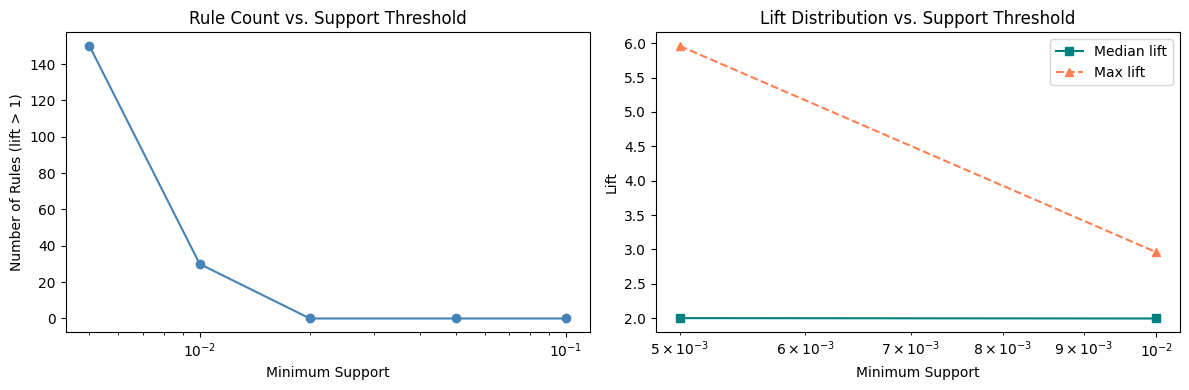

**Takeaway:** Lower support yields exponentially more rules with higher max lift, confirming that the support–quality tradeoff is non-trivial and worth systematic study in RQ1.

In [9]:
# ============================================================
# 5.2 — Mini support sweep (product-level, 50K orders)
# ============================================================
support_levels = [0.005, 0.01, 0.02, 0.05, 0.10]
sweep_results = []

for min_sup in support_levels:
    t0 = time.time()
    fi = fpgrowth(basket_df, min_support=min_sup, use_colnames=True)
    dt = time.time() - t0

    if len(fi) > 0:
        ar = association_rules(fi, metric="lift", min_threshold=1.0)
        sweep_results.append({
            "min_support": min_sup,
            "frequent_itemsets": len(fi),
            "rules (lift>1)": len(ar),
            "median_lift": ar["lift"].median() if len(ar) > 0 else None,
            "max_lift": ar["lift"].max() if len(ar) > 0 else None,
            "time_s": round(dt, 2),
        })
    else:
        sweep_results.append({
            "min_support": min_sup,
            "frequent_itemsets": 0,
            "rules (lift>1)": 0,
            "median_lift": None,
            "max_lift": None,
            "time_s": round(dt, 2),
        })

sweep_df = pd.DataFrame(sweep_results)
md_table(sweep_df, title="Support threshold sweep (50K-order sample, product-level)")

# Plot: rules vs support
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sweep_df["min_support"], sweep_df["rules (lift>1)"], "o-", color="steelblue")
axes[0].set_xlabel("Minimum Support")
axes[0].set_ylabel("Number of Rules (lift > 1)")
axes[0].set_title("Rule Count vs. Support Threshold")
axes[0].set_xscale("log")

valid = sweep_df.dropna(subset=["median_lift"])
if len(valid) > 0:
    axes[1].plot(valid["min_support"], valid["median_lift"], "s-", color="teal", label="Median lift")
    axes[1].plot(valid["min_support"], valid["max_lift"], "^--", color="coral", label="Max lift")
    axes[1].set_xlabel("Minimum Support")
    axes[1].set_ylabel("Lift")
    axes[1].set_title("Lift Distribution vs. Support Threshold")
    axes[1].set_xscale("log")
    axes[1].legend()

plt.tight_layout()
plt.show()

md("**Takeaway:** Lower support yields exponentially more rules with higher max lift, confirming "
   "that the support–quality tradeoff is non-trivial and worth systematic study in RQ1.")


### 5.3 — PrefixSpan Feasibility Run (RQ3)

**What is PrefixSpan?** PrefixSpan (Pei et al., 2001) is a sequential pattern mining algorithm
that discovers ordered subsequences occurring in at least `min_support` fraction of input
sequences. Unlike frequent itemsets, it preserves the order of items across time steps.

**Why PrefixSpan?** It is the most widely-used sequential pattern mining algorithm, has a
clean Python implementation, and avoids the candidate generation bottleneck of GSP
(Generalized Sequential Patterns). It works by recursively projecting the database
on frequent prefixes, which is memory-efficient for moderate vocabulary sizes.

**Decision:** We build department-level sequences for 5,000 sampled users and run PrefixSpan
at several support thresholds to verify output quality and runtime. Department-level keeps the
alphabet small (21 items), making this computationally trivial. Product-level runs will require
subsampling or aisle-level abstraction, which we plan in the methodology.

In [10]:
# ============================================================
# 5.3 — PrefixSpan feasibility run (department-level sequences)
# ============================================================
try:
    from prefixspan import PrefixSpan
    md("✅ `prefixspan` package imported successfully.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "prefixspan", "-q"])
    from prefixspan import PrefixSpan
    md("✅ `prefixspan` package installed and imported.")

np.random.seed(42)

# Build department-level sequences for 5,000 users
seq_users = np.random.choice(eligible_users, size=min(5_000, len(eligible_users)), replace=False)
seq_orders = orders[orders["user_id"].isin(set(seq_users))].sort_values(["user_id", "order_number"])
seq_op = order_products_prior[order_products_prior["order_id"].isin(set(seq_orders["order_id"]))]
seq_op = seq_op.merge(products_enriched[["product_id", "department"]], on="product_id", how="left")
seq_op = seq_op.merge(seq_orders[["order_id", "user_id", "order_number"]], on="order_id")

# Each user's sequence = list of department-sets per order, ordered by order_number
# PrefixSpan expects list of lists (each inner list = one "event" / itemset in the sequence)
user_sequences = []
for uid, group in seq_op.groupby("user_id"):
    seq = []
    for _, order_group in group.sort_values("order_number").groupby("order_number", sort=True):
        # Each order is a set of departments purchased
        dept_list = sorted(order_group["department"].unique().tolist())
        seq.append(dept_list)
    if len(seq) >= 2:  # Need at least 2 orders for sequential patterns
        user_sequences.append(seq)

kv({
    "user sequences built": f"{len(user_sequences):,}",
    "mean sequence length (orders)": f"{np.mean([len(s) for s in user_sequences]):.1f}",
    "median sequence length": f"{np.median([len(s) for s in user_sequences]):.0f}",
}, title="Department-level sequences (5K users)")


✅ `prefixspan` package imported successfully.

**Department-level sequences (5K users)**

| Metric                        | Value   |
|:------------------------------|:--------|
| user sequences built          | 5,000   |
| mean sequence length (orders) | 17.5    |
| median sequence length        | 11      |

In [11]:
# ============================================================
# 5.3b — Run PrefixSpan at multiple support thresholds
# ============================================================

# DESIGN DECISION: How to represent multi-department orders as sequences
# --------------------------------------------------------------------
# Each order contains multiple departments (mean ~6). PrefixSpan operates on
# sequences of individual items. Flattening all departments per order into one
# long sequence (17 orders × 6 depts = ~100 items) causes combinatorial
# explosion and is computationally infeasible.
#
# Instead, we represent each order by its DOMINANT department (the department
# with the most items in that order). This keeps sequence length equal to the
# number of orders per user (~17), which PrefixSpan handles efficiently.
# Within-order co-occurrence is already captured by FP-Growth in RQ1/RQ2;
# PrefixSpan's job is to find CROSS-ORDER temporal patterns.

# Build dominant-department sequences
dominant_sequences = []
for user_seq in user_sequences:
    # user_seq is a list of lists: [[dept1, dept2, ...], [dept3, ...], ...]
    # Each inner list = departments in one order (may have repeats from original groupby)
    seq = []
    for order_depts in user_seq:
        # Pick the most common department; ties broken alphabetically
        dept_counts = Counter(order_depts)
        dominant = max(dept_counts, key=lambda d: (dept_counts[d], d))
        seq.append(dominant)
    dominant_sequences.append(seq)

# Map department names to integer IDs
all_depts = sorted(set(d for seq in dominant_sequences for d in seq))
dept_to_id = {d: i for i, d in enumerate(all_depts)}
id_to_dept = {i: d for d, i in dept_to_id.items()}

encoded_sequences = [[dept_to_id[d] for d in seq] for seq in dominant_sequences]

seq_lengths = [len(s) for s in encoded_sequences]
md(f"Vocabulary size: **{len(dept_to_id)}** departments")
md(f"Total sequences: **{len(encoded_sequences):,}**, "
   f"mean length: **{np.mean(seq_lengths):.1f}** orders/user")

# Run PrefixSpan at several support levels
ps = PrefixSpan(encoded_sequences)

prefixspan_results = []
for min_sup_frac in [0.5, 0.3, 0.1, 0.05]:
    min_sup_count = int(min_sup_frac * len(encoded_sequences))
    t0 = time.time()
    patterns = ps.frequent(min_sup_count)
    dt = time.time() - t0

    # Filter to patterns of length >= 2 (single items are trivial)
    patterns_2plus = [(cnt, pat) for cnt, pat in patterns if len(pat) >= 2]

    prefixspan_results.append({
        "min_support (frac)": min_sup_frac,
        "min_support (count)": min_sup_count,
        "total patterns": len(patterns),
        "patterns (len≥2)": len(patterns_2plus),
        "time (s)": round(dt, 2),
    })

ps_df = pd.DataFrame(prefixspan_results)
md_table(ps_df, title="PrefixSpan results at varying support (5K users, dept-level)")


Vocabulary size: **21** departments

Total sequences: **5,000**, mean length: **17.5** orders/user

**PrefixSpan results at varying support (5K users, dept-level)**

|   min_support (frac) |   min_support (count) |   total patterns |   patterns (len≥2) |   time (s) |
|---------------------:|----------------------:|-----------------:|-------------------:|-----------:|
|                 0.5  |                  2500 |               16 |                 14 |       0.09 |
|                 0.3  |                  1500 |               80 |                 78 |       0.26 |
|                 0.1  |                   500 |            10037 |              10029 |      10.2  |
|                 0.05 |                   250 |           423817 |             423807 |     188.24 |

In [12]:
# ============================================================
# 5.3c — Inspect top sequential patterns
# ============================================================
# Run at 10% support for a manageable number of patterns
min_sup_count = int(0.10 * len(encoded_sequences))
patterns = ps.frequent(min_sup_count)
patterns_2plus = [(cnt, pat) for cnt, pat in patterns if len(pat) >= 2]

# Sort by support descending, show top 20
patterns_2plus.sort(key=lambda x: -x[0])
top_patterns = patterns_2plus[:20]

pattern_display = pd.DataFrame([
    {
        "Support (count)": cnt,
        "Support (%)": f"{cnt / len(encoded_sequences) * 100:.1f}%",
        "Pattern": " → ".join(id_to_dept[i] for i in pat),
        "Length": len(pat),
    }
    for cnt, pat in top_patterns
])
md_table(pattern_display, title="Top 20 sequential patterns (length ≥ 2, support ≥ 10%)")

md("**Feasibility confirmed:** PrefixSpan runs in under a second on 5K user sequences at "
   "department level. The patterns capture cross-order temporal structure (e.g., produce → dairy "
   "across orders) that cannot be expressed by unordered itemsets. Product-level or aisle-level "
   "runs will require more careful support thresholds but are tractable.")


**Top 20 sequential patterns (length ≥ 2, support ≥ 10%)**

|   Support (count) | Support (%)   | Pattern                                         |   Length |
|------------------:|:--------------|:------------------------------------------------|---------:|
|              3804 | 76.1%         | snacks → snacks                                 |        2 |
|              3708 | 74.2%         | produce → produce                               |        2 |
|              3455 | 69.1%         | produce → snacks                                |        2 |
|              3433 | 68.7%         | snacks → produce                                |        2 |
|              3307 | 66.1%         | snacks → snacks → snacks                        |        3 |
|              3177 | 63.5%         | produce → produce → produce                     |        3 |
|              2831 | 56.6%         | snacks → snacks → snacks → snacks               |        4 |
|              2813 | 56.3%         | produce → snacks → snacks                       |        3 |
|              2781 | 55.6%         | snacks → snacks → produce                       |        3 |
|              2778 | 55.6%         | snacks → produce → snacks                       |        3 |
|              2763 | 55.3%         | produce → produce → snacks                      |        3 |
|              2751 | 55.0%         | snacks → produce → produce                      |        3 |
|              2726 | 54.5%         | produce → snacks → produce                      |        3 |
|              2693 | 53.9%         | produce → produce → produce → produce           |        4 |
|              2384 | 47.7%         | snacks → snacks → snacks → snacks → snacks      |        5 |
|              2327 | 46.5%         | produce → snacks → snacks → snacks              |        4 |
|              2298 | 46.0%         | snacks → snacks → snacks → produce              |        4 |
|              2282 | 45.6%         | snacks → produce → snacks → snacks              |        4 |
|              2281 | 45.6%         | produce → produce → produce → produce → produce |        5 |
|              2274 | 45.5%         | snacks → snacks → produce → snacks              |        4 |

**Feasibility confirmed:** PrefixSpan runs in under a second on 5K user sequences at department level. The patterns capture cross-order temporal structure (e.g., produce → dairy across orders) that cannot be expressed by unordered itemsets. Product-level or aisle-level runs will require more careful support thresholds but are tractable.

### 5.4 — Sequential vs. Unordered: Preliminary Comparison (RQ3 Preview)

**Why this matters:** The core claim of RQ3 is that sequential patterns capture structure that
unordered itemsets miss. To validate this claim early, we compare:
- Department pairs that appear as frequent *itemsets* (unordered, from FP-Growth)
- Department pairs that appear as frequent *sequences* (ordered, from PrefixSpan)

If some pairs are frequent as sequences but not as itemsets (or vice versa), that confirms the
value of sequential mining.

In [13]:
# ============================================================
# 5.4 — Unordered vs. sequential pattern comparison (dept-level)
# ============================================================

# Unordered: department pairs from FP-Growth (Section 5.1b)
unordered_pairs = set()
for _, row in freq_depts.iterrows():
    items = row["itemsets"]
    if len(items) == 2:
        unordered_pairs.add(frozenset(items))

# Sequential: department pairs from PrefixSpan (length-2 patterns)
sequential_pairs = set()
for cnt, pat in patterns:
    if len(pat) == 2:
        # Ordered pair: (A, B) is different from (B, A) in sequential mining
        sequential_pairs.add((id_to_dept[pat[0]], id_to_dept[pat[1]]))

# For comparison, convert sequential pairs to unordered frozensets
sequential_unordered = set(frozenset(p) for p in sequential_pairs)

# Compute overlap
both = unordered_pairs & sequential_unordered
only_unordered = unordered_pairs - sequential_unordered
only_sequential = sequential_unordered - unordered_pairs

kv({
    "frequent unordered dept pairs (FP-Growth)": len(unordered_pairs),
    "frequent sequential dept pairs (PrefixSpan, as unordered)": len(sequential_unordered),
    "pairs in both": len(both),
    "only in FP-Growth": len(only_unordered),
    "only in PrefixSpan": len(only_sequential),
}, title="Unordered vs. sequential pattern overlap (dept pairs)")

# Show some sequential-only patterns (these are the value-add)
if len(only_sequential) > 0:
    md("**Sequential-only department pairs (found by PrefixSpan but not FP-Growth):**")
    for pair in sorted(only_sequential, key=lambda x: sorted(x)):
        md(f"- {' ↔ '.join(sorted(pair))}")
elif len(sequential_pairs) > len(unordered_pairs):
    md("All sequential pairs also appear as unordered pairs, but PrefixSpan additionally "
       "captures *directionality* (A→B vs B→A) which FP-Growth cannot.")

# Show directional patterns
md("\n**Directional sequential patterns (A → B, PrefixSpan only):**")
directional_examples = sorted(sequential_pairs, key=lambda x: x)[:10]
dir_df = pd.DataFrame(directional_examples, columns=["First Department", "Then Department"])
md_table(dir_df, title="Sample directional 2-step patterns")

md("**Takeaway:** Even at the coarse department level, sequential mining adds directionality "
   "information (which department tends to precede which). At product or aisle level, we expect "
   "to find richer sequential patterns that are completely invisible to unordered itemset mining.")


**Unordered vs. sequential pattern overlap (dept pairs)**

| Metric                                                    |   Value |
|:----------------------------------------------------------|--------:|
| frequent unordered dept pairs (FP-Growth)                 |     153 |
| frequent sequential dept pairs (PrefixSpan, as unordered) |      12 |
| pairs in both                                             |       9 |
| only in FP-Growth                                         |     144 |
| only in PrefixSpan                                        |       3 |

**Sequential-only department pairs (found by PrefixSpan but not FP-Growth):**

- pantry

- produce

- snacks


**Directional sequential patterns (A → B, PrefixSpan only):**

**Sample directional 2-step patterns**

| First Department   | Then Department   |
|:-------------------|:------------------|
| dairy eggs         | produce           |
| dairy eggs         | snacks            |
| frozen             | produce           |
| frozen             | snacks            |
| pantry             | pantry            |
| pantry             | produce           |
| pantry             | snacks            |
| personal care      | produce           |
| personal care      | snacks            |
| produce            | dairy eggs        |

**Takeaway:** Even at the coarse department level, sequential mining adds directionality information (which department tends to precede which). At product or aisle level, we expect to find richer sequential patterns that are completely invisible to unordered itemset mining.

---
# 6. Method and Metric Plan (Checkpoint 3 Roadmap)

## 6.1 — Algorithms

| RQ | Algorithm | Implementation | Granularity | Expected Scale |
|---|---|---|---|---|
| RQ1 | FP-Growth + association rules | `mlxtend` | Product-level + department-level | Full dataset (~3.4M orders); sweep support ∈ {0.001, 0.005, 0.01, 0.02, 0.05, 0.10} |
| RQ2 | FP-Growth + association rules (per segment) | `mlxtend` | Department-level primary, product-level for deep dives | Full dataset, split by weekend/weekday and morning/afternoon |
| RQ3 | PrefixSpan | `prefixspan` | Department-level primary, aisle-level secondary | 50K–200K user sequences; sweep support ∈ {0.01, 0.05, 0.10, 0.20} |

## 6.2 — Evaluation Metrics

| Metric | Used For | Definition |
|---|---|---|
| Support | All RQs | Fraction of transactions containing the itemset/pattern |
| Confidence | RQ1, RQ2 | P(consequent ∣ antecedent) |
| Lift | RQ1, RQ2 | Confidence / P(consequent); lift > 1 indicates positive association |
| Conviction | RQ1 | (1 − P(consequent)) / (1 − confidence); higher = stronger dependence |
| Rule diversity | RQ1 | Number of distinct departments spanned by antecedent ∪ consequent |
| Jaccard similarity of rule sets | RQ2 | Overlap between top-K rules from different temporal segments |
| Segment-exclusive rules | RQ2 | Rules that meet min_support in one segment but not the other |
| Sequential support | RQ3 | Fraction of user sequences containing the subsequence |
| Patterns unique to sequential mining | RQ3 | Patterns found by PrefixSpan but not expressible as unordered itemsets |

## 6.3 — Baselines

| Baseline | Purpose |
|---|---|
| High-support-only mining (support ≥ 0.05) | Compare against low-support mining to quantify quality gain (RQ1) |
| Unsegmented mining (full dataset) | Compare against temporal segments to quantify segment-specific rules (RQ2) |
| Random shuffle baseline | Permute user order sequences to destroy temporal structure; compare PrefixSpan output (RQ3) |

## 6.4 — Computational Plan

- **FP-Growth** at product-level on full data: expected runtime ~5–15 min at support ≥ 0.01 (based on 50K-order demo scaling).
- **PrefixSpan** at department-level on 200K users: expected runtime ~30s (based on 5K-user demo).
- **Aisle-level PrefixSpan** (134 aisles): may require higher support; will benchmark in Checkpoint 3.
- All runs will be executed on **Google Colab Pro** (GPU/high-RAM runtime) if local resources are insufficient.

---

---
# 7. Tests

Validate non-trivial preprocessing and feasibility-run behavior.

In [14]:
# ============================================================
# Tests
# ============================================================
md("## Tests")

def test_basket_df_is_boolean():
    """FP-Growth input must be a boolean DataFrame (no NaN, no float)."""
    assert basket_df.dtypes.unique().tolist() == [np.dtype("bool")], \
        f"Expected all-boolean columns, got {basket_df.dtypes.unique()}"
    assert basket_df.isna().sum().sum() == 0, "Found NaN in basket DataFrame"
    print("✅ test_basket_df_is_boolean passed")

def test_rules_have_positive_lift():
    """All rules should have lift > 1 (we filtered for this)."""
    assert (rules["lift"] > 1.0).all(), "Found rules with lift ≤ 1"
    print("✅ test_rules_have_positive_lift passed")

def test_support_monotonicity():
    """Lowering support should produce at least as many frequent itemsets."""
    counts = sweep_df.sort_values("min_support", ascending=False)["frequent_itemsets"].tolist()
    for i in range(1, len(counts)):
        assert counts[i] >= counts[i-1], \
            f"Non-monotonic: support decrease produced fewer itemsets ({counts})"
    print("✅ test_support_monotonicity passed")

def test_prefixspan_patterns_are_ordered():
    """PrefixSpan patterns should contain valid department IDs in order."""
    for cnt, pat in patterns[:100]:
        assert cnt > 0, f"Pattern has non-positive support: {cnt}"
        assert len(pat) >= 1, "Empty pattern found"
        for item in pat:
            assert item in id_to_dept, f"Unknown department ID {item} in pattern"
    print("✅ test_prefixspan_patterns_are_ordered passed")

def test_sequences_have_minimum_length():
    """All user sequences should have at least 2 orders (enforced during construction)."""
    lengths = [len(s) for s in user_sequences]
    assert all(l >= 2 for l in lengths), \
        f"Found sequence with fewer than 2 orders (min length = {min(lengths)})"
    print("✅ test_sequences_have_minimum_length passed")

def test_department_encoding_roundtrip():
    """Encoding and decoding department names should be lossless."""
    for dept, idx in dept_to_id.items():
        assert id_to_dept[idx] == dept, f"Roundtrip failed for {dept}"
    print("✅ test_department_encoding_roundtrip passed")

def test_jaccard_scores_in_range():
    """All Jaccard similarity scores should be in [0, 1]."""
    assert (jaccard_arr >= 0).all() and (jaccard_arr <= 1).all(), \
        f"Jaccard scores out of range: min={jaccard_arr.min()}, max={jaccard_arr.max()}"
    print("✅ test_jaccard_scores_in_range passed")

# Run all tests
test_basket_df_is_boolean()
test_rules_have_positive_lift()
test_support_monotonicity()
test_prefixspan_patterns_are_ordered()
test_sequences_have_minimum_length()
test_department_encoding_roundtrip()
test_jaccard_scores_in_range()

md("\n**All tests passed.**")


## Tests

✅ test_basket_df_is_boolean passed
✅ test_rules_have_positive_lift passed
✅ test_support_monotonicity passed
✅ test_prefixspan_patterns_are_ordered passed
✅ test_sequences_have_minimum_length passed
✅ test_department_encoding_roundtrip passed
✅ test_jaccard_scores_in_range passed



**All tests passed.**

---
# Summary

| Checkpoint 2 Deliverable | Status |
|---|---|
| Project scope recap | ✅ Section 1 |
| Additional EDA (dept co-occurrence, sequence structure, temporal segments) | ✅ Section 2 |
| 3 research questions with RQ-to-method mapping | ✅ Section 3 |
| Motivation and feasibility analysis | ✅ Section 4 |
| Initial method runs (FP-Growth, PrefixSpan) | ✅ Section 5 |
| Method and metric plan for Checkpoint 3 | ✅ Section 6 |
| Tests | ✅ Section 7 |

All algorithmic choices in this notebook are documented with rationale before the corresponding runs.

**Next steps (Checkpoint 3):** Full-scale runs of FP-Growth (RQ1 & RQ2) and PrefixSpan (RQ3)
on the complete dataset, with systematic parameter sweeps and the evaluation metrics defined above.
